<a href="https://colab.research.google.com/github/47MAK/Facial-Emotion-Detection-Using-CNN/blob/main/Copy_of_Facial_Emotion_Detection_Using_CNN1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing all the required Libraries for Model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D,MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization,Activation, GlobalAveragePooling2D

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras import Model
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np
import cv2
import os

# Removing all those annoying Warnings

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("✅ Google Drive forcefully remounted. Please re-run the cell with ID XnuWSw2KwXaI.")

Mounted at /content/drive
✅ Google Drive forcefully remounted. Please re-run the cell with ID XnuWSw2KwXaI.


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/fer2013.zip"  # change if your name differs
extract_path = "/content/dataset"

# Ensure the extraction directory exists before extraction
os.makedirs(extract_path, exist_ok=True)

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print(f"Attempting to extract {zip_path} to {extract_path}...")
        zip_ref.extractall(extract_path)
    print("Extraction command completed.")
except FileNotFoundError:
    print(f"Error: Zip file not found at {zip_path}. Please check the path and ensure the file is in your Google Drive.")
except zipfile.BadZipFile:
    print(f"Error: The file at {zip_path} is not a valid zip file or is corrupted.")
except Exception as e:
    print(f"An unexpected error occurred during extraction: {e}")

# Verify contents after extraction
print(f"\nContents of {extract_path} after extraction:")
if os.path.exists(extract_path):
    contents = os.listdir(extract_path)
    if contents:
        print("Files/directories found:")
        for item in contents:
            print(f"- {item}")
    else:
        print("Directory exists but is empty. Extraction might have failed or the zip was empty.")
else:
    print("Error: Extraction path does not exist after attempted extraction. This is unexpected if os.makedirs was successful.")


Attempting to extract /content/drive/MyDrive/fer2013.zip to /content/dataset...
Extraction command completed.

Contents of /content/dataset after extraction:
Files/directories found:
- data


In [ ]:
# Define dataset paths
train_path = "/content/dataset/data/train"
test_path = "/content/dataset/data/test"


In [ ]:
# Define a mapping from emotion names to numerical folder labels
emotion_map = {
    'angry': '0',
    'disgust': '1',
    'fear': '2',
    'happy': '3',
    'sad': '4',
    'surprise': '5',
    'neutral': '6'
}

# Create a reverse mapping for easier lookup of names from numbers (optional, but useful)
inv_emotion_map = {v: k for k, v in emotion_map.items()}

print("Emotion to numerical label mapping created:", emotion_map)


Emotion to numerical label mapping created: {'angry': '0', 'disgust': '1', 'fear': '2', 'happy': '3', 'sad': '4', 'surprise': '5', 'neutral': '6'}


In [ ]:
import os

# Define the extraction path
extract_path = "/content/dataset"

print(f"Checking contents of: {extract_path}")

if os.path.exists(extract_path):
    contents = os.listdir(extract_path)
    if contents:
        print("Contents found:")
        for item in contents:
            print(f"- {item}")
    else:
        print("Directory exists but is empty.")
        print("This suggests the zip file was empty or extraction failed.")
else:
    print("Error: Directory /content/dataset does not exist.")
    print("This means the zip file was not extracted or extraction path is incorrect.")

# Note: The original intent was to check 'test_path'.
# If the above check reveals a subfolder (e.g., 'fer2013'),
# you will need to update `train_path` and `test_path` in cell `rRpp9rwXjuqD` accordingly.
# Example: train_path = "/content/dataset/fer2013/train"

Checking contents of: /content/dataset
Contents found:
- data


In [ ]:
import os

# List the contents of /content/dataset/data
data_contents = os.listdir('/content/dataset/data')
print(f"Contents of /content/dataset/data: {data_contents}")


Contents of /content/dataset/data: ['train', 'test', 'val']


In [ ]:
#list the directory of trian path
os.listdir(train_path)

['0', '4', '3', '2', '5', '1', '6']

In [ ]:
# Getting the first image from the 'angry' folder using the emotion map
# The numerical label for 'angry' is emotion_map['angry'] (which is '0')
os.listdir(train_path + '/' + emotion_map['angry'])[0]


'19667.png'

In [ ]:
import os
# Constructing the path to an image in the 'angry' folder using the emotion map
img = os.path.join(train_path, emotion_map['angry'], 'Training_52927331.jpg')


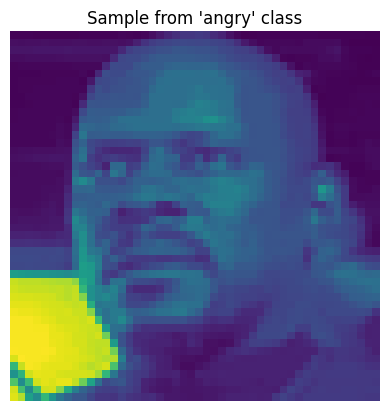

In [ ]:
import os
from matplotlib.image import imread
import matplotlib.pyplot as plt

# Dynamically get the first image path from the 'angry' folder (label '0')
angry_folder_path = os.path.join(train_path, emotion_map['angry'])
first_image_name = os.listdir(angry_folder_path)[0]
img_to_show = os.path.join(angry_folder_path, first_image_name)

# Showing the first image of the angry folder
plt.imshow(imread(img_to_show))
plt.title(f"Sample from '{inv_emotion_map[emotion_map['angry']]}' class")
plt.axis('off')
plt.show()

In [ ]:
#define a function to plot some images from different classes

def plot_images(img_dir, top=10):
    all_img_dirs = os.listdir(img_dir)
    img_files = [os.path.join(img_dir, file) for file in all_img_dirs][:5]

    plt.figure(figsize=(10, 10))

    for idx, img_path in enumerate(img_files):
        plt.subplot(5, 5, idx+1)

        img = plt.imread(img_path)
        plt.tight_layout()
        plt.imshow(img, cmap='gray')

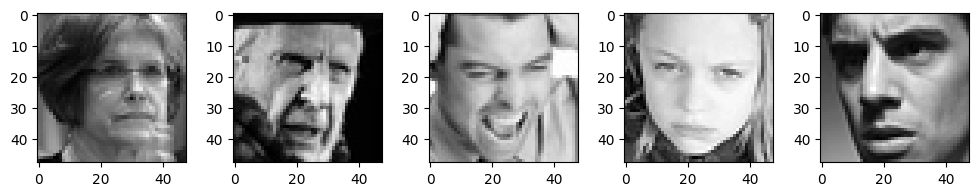

In [ ]:
# Sample of angry class using the emotion map
plot_images(os.path.join(train_path, emotion_map['angry']))


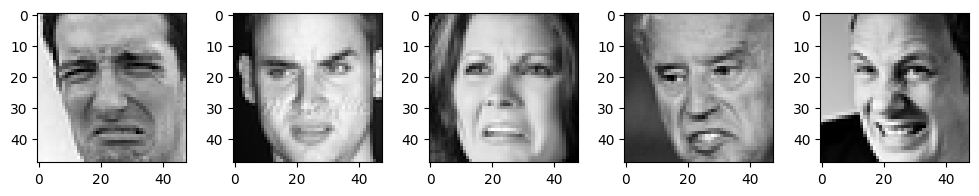

In [ ]:
# Sample of disgust class using the emotion map
plot_images(os.path.join(train_path, emotion_map['disgust']))


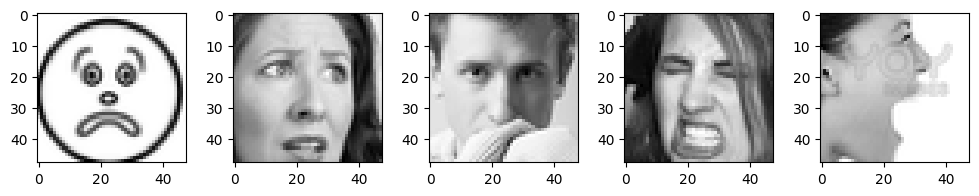

In [ ]:
# Sample of fear class using the emotion map
plot_images(os.path.join(train_path, emotion_map['fear']))


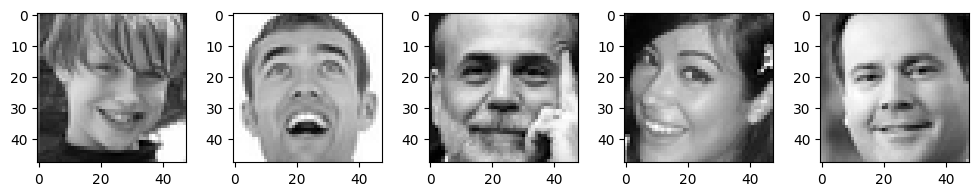

In [ ]:
# Sample of happy class using the emotion map
plot_images(os.path.join(train_path, emotion_map['happy']))


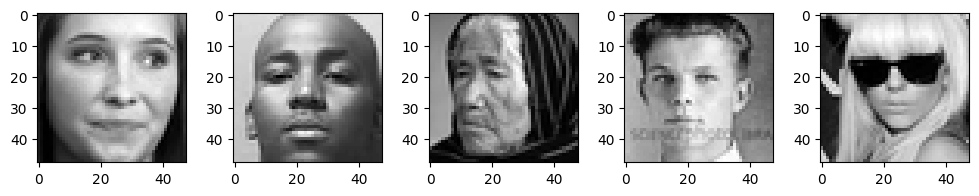

In [ ]:
# Sample of neutral class using the emotion map
plot_images(os.path.join(train_path, emotion_map['neutral']))


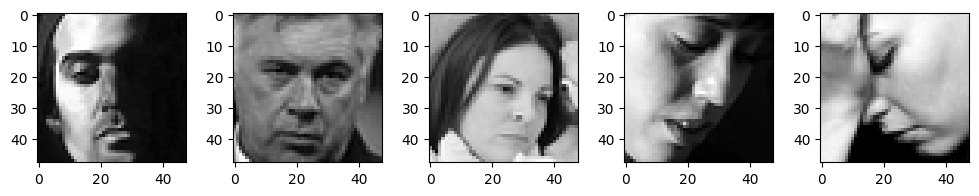

In [ ]:
# Sample of sad class using the emotion map
plot_images(os.path.join(train_path, emotion_map['sad']))


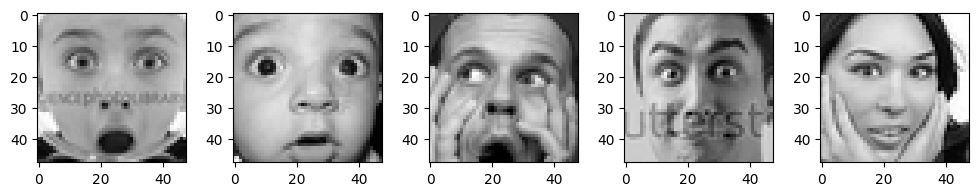

In [ ]:
# Sample of surprise class using the emotion map
plot_images(os.path.join(train_path, emotion_map['surprise']))


In [ ]:
for expression_label in os.listdir(train_path):
    # Get the emotion name from the numerical label using inv_emotion_map
    emotion_name = inv_emotion_map.get(expression_label, f"Unknown ({expression_label})")
    print(f"{len(os.listdir(os.path.join(train_path, expression_label)))} {emotion_name} images")


3171 surprise images
4097 fear images
4965 neutral images
436 disgust images
4830 sad images
3995 angry images
7215 happy images


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data generator WITH augmentation + validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='reflect',
    validation_split=0.2  # 20% of training data for validation
)

# Testing generator (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Parameters
IMG_SIZE = (48, 48)
BATCH_SIZE = 64

# Training subset
train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    subset='training',
    shuffle=True
)

# Validation subset
val_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    subset='validation',
    shuffle=True
)

# Test set (no augmentation)
test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Check dataset sizes
print(f"✅ Train samples: {train_gen.samples}")
print(f"✅ Validation samples: {val_gen.samples}")
print(f"✅ Test samples: {test_gen.samples}")

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
✅ Train samples: 22968
✅ Validation samples: 5741
✅ Test samples: 3589


✅ Class label mapping: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6}
✅ Computed Class Weights: {0: np.float32(1.0266404), 1: np.float32(9.401555), 2: np.float32(1.0009588), 3: np.float32(0.56845856), 4: np.float32(0.84915704), 5: np.float32(1.293316), 6: np.float32(0.82606816)}


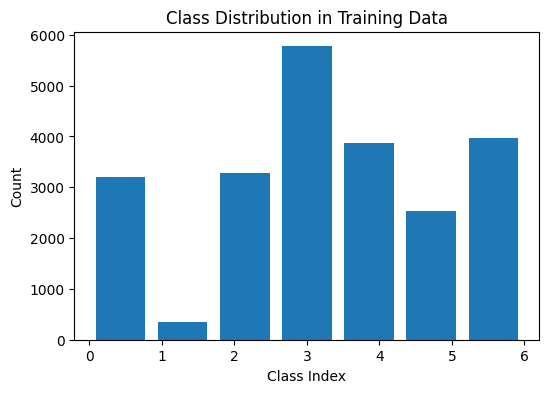

In [ ]:
# ==========================================================
# ✅ Compute Class Weights for Imbalanced FER-13 Dataset
# ==========================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

# Get class labels (integer indices for each image)
class_labels = train_gen.classes
class_indices = train_gen.class_indices

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
).astype(np.float32)

# Convert to dictionary {class_index: weight_value}
class_weights_dict = dict(enumerate(class_weights))

# Print class mapping and weights
print("✅ Class label mapping:", class_indices)
print("✅ Computed Class Weights:", class_weights_dict)

# Optional: visualize imbalance (for understanding)
plt.figure(figsize=(6,4))
plt.hist(class_labels, bins=len(class_indices), rwidth=0.8)
plt.title("Class Distribution in Training Data")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()


In [ ]:
#printing the class indicies og train_gen
print(train_gen.class_indices)

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6}


Image pixel range: min=0.000, max=1.000


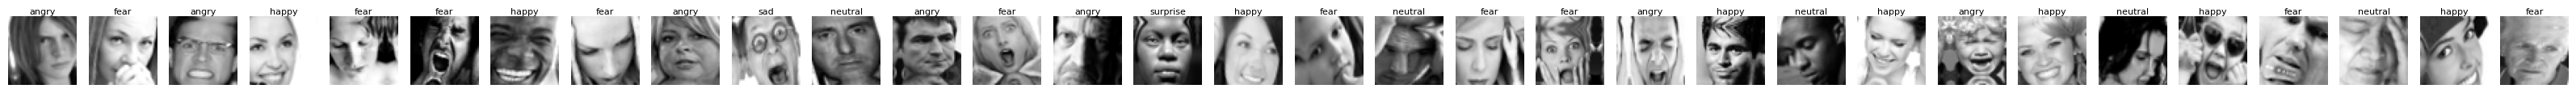

In [ ]:
# ==========================================================
# ✅ Visualize a Batch of Training Images with Labels
# ==========================================================

# Get one random batch from training generator
imgs, labels = next(train_gen)

# Define class names (must match your dataset order)
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Confirm normalization (should be in range 0–1)
print(f"Image pixel range: min={imgs.min():.3f}, max={imgs.max():.3f}")

# Visualization function
def plotImages(images_arr, labels_arr, class_names):
    n = len(images_arr)
    fig, axes = plt.subplots(1, n, figsize=(n, 2))
    axes = np.ravel(axes)

    for i in range(n):
        img = images_arr[i].squeeze()  # Remove channel dimension if grayscale
        label_index = np.argmax(labels_arr[i])
        label_name = class_names[label_index]
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(label_name, fontsize=8, pad=2)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Plot up to 32 images (or fewer if batch smaller)
plotImages(imgs[:32], labels[:32], class_names)


In [ ]:
# ==========================================================
# ✅ Optimized CNN Architecture for FER-13 (from scratch)
# ==========================================================
from tensorflow.keras.regularizers import l2

no_of_classes = 7

model = Sequential([
    # Block 1
    Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal',
           kernel_regularizer=l2(1e-4), input_shape=(48,48,1)),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),

    # Block 2
    Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),

    # Block 3
    Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.4),

    # Global Pooling instead of Flatten
    GlobalAveragePooling2D(),

    # Dense layers
    Dense(256, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output layer
    Dense(no_of_classes, activation='softmax')
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 12, 12, 256)    │             

 Total params: 1,216,455 (4.64 MB)

 Trainable params: 1,214,151 (4.63 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import losses, metrics

# ✅ Compile the model with improved loss and metrics
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)



In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

# ==========================================================
# ✅ Callbacks for FER-13 Training
# ==========================================================

# Save the best model based on validation loss
checkpoint = ModelCheckpoint(
    filepath='best_fer13_cnn.h5',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# Stop training if no improvement in validation loss for 10 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

# Reduce LR when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # reduce LR by half
    patience=4,       # wait 4 epochs before reducing
    verbose=1,
    min_lr=1e-6
)

# Optional: Log training progress to a CSV file
csv_logger = CSVLogger('training_log.csv', append=True)

# Combine all callbacks
callbacks = [checkpoint, early_stopping, reduce_lr, csv_logger]


In [ ]:
# ==========================================================
# ✅ Train the Model (Optimized Configuration)
# ==========================================================

history = model.fit(
    train_gen,
    validation_data=val_gen,            # <-- Use validation split instead of test set
    epochs=60,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)


Epoch 1/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.1512 - loss: 2.4628 - precision: 0.1565 - recall: 0.0174
Epoch 1: val_loss improved from None to 2.11428, saving model to best_fer13_cnn.h5



Epoch 1: finished saving model to best_fer13_cnn.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 58s 127ms/step - accuracy: 0.1520 - loss: 2.3861 - precision: 0.1496 - recall: 0.0117 - val_accuracy: 0.1648 - val_loss: 2.1143 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1708 - loss: 2.2311 - precision: 0.1424 - recall: 0.0063
Epoch 2: val_loss improved from 2.11428 to 2.07277, saving model to best_fer13_cnn.h5



Epoch 2: finished saving model to best_fer13_cnn.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 36s 99ms/step - accuracy: 0.1644 - loss: 2.2320 - precision: 0.1325 - recall: 0.0053 - val_accuracy: 0.1740 - val_loss: 2.0728 - val_precision: 0.1500 - val_recall: 5.2256e-04 - learning_rate: 0.0010
Epoch 3/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1551 - loss: 2.1846 - precision: 0.1285 - recall: 0.0035
Epoch 3: val_loss did not improve from 2.07277
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 96ms/step - accuracy: 0.1606 - loss: 2.1408 - precision: 0.1429 - recall: 0.0030 - val_accuracy: 0.1589 - val_loss: 2.0910 - val_precision: 0.3548 - val_recall: 0.0019 - learning_rate: 0.0010
Epoch 4/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1874 - loss: 2.1021 - precision: 0.2810 - recall: 0.0043
Epoch 4: val_loss improved from 2.07277 to 2.00167, saving model to best_fer13_cnn.h5



Epoch 4: finished saving model to best_fer13_cnn.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.1854 - loss: 2.0607 - precision: 0.2908 - recall: 0.0054 - val_accuracy: 0.2273 - val_loss: 2.0017 - val_precision: 0.5882 - val_recall: 0.0017 - learning_rate: 0.0010
Epoch 5/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.2045 - loss: 1.9736 - precision: 0.4642 - recall: 0.0161
Epoch 5: val_loss did not improve from 2.00167
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.2016 - loss: 1.9880 - precision: 0.5055 - recall: 0.0202 - val_accuracy: 0.1413 - val_loss: 2.2763 - val_precision: 0.2516 - val_recall: 0.0754 - learning_rate: 0.0010
Epoch 6/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2191 - loss: 1.9376 - precision: 0.5353 - recall: 0.0319
Epoch 6: val_loss did not improve from 2.00167
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.2308 - loss: 1.9320 - precision: 0.5639 - recall: 0.0336 - val_accuracy: 0.1972 - val_loss: 2.0666


Epoch 7: finished saving model to best_fer13_cnn.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.2740 - loss: 1.8799 - precision: 0.5735 - recall: 0.0423 - val_accuracy: 0.3149 - val_loss: 1.8508 - val_precision: 0.6475 - val_recall: 0.0726 - learning_rate: 0.0010
Epoch 8/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3059 - loss: 1.8433 - precision: 0.5865 - recall: 0.0602
Epoch 8: val_loss did not improve from 1.85081
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.3174 - loss: 1.8338 - precision: 0.6112 - recall: 0.0681 - val_accuracy: 0.2588 - val_loss: 1.9883 - val_precision: 0.4697 - val_recall: 0.0608 - learning_rate: 0.0010
Epoch 9/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3359 - loss: 1.8274 - precision: 0.6310 - recall: 0.0904
Epoch 9: val_loss did not improve from 1.85081
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.3568 - loss: 1.7866 - precision: 0.6589 - recall: 0.1050 - val_accuracy: 0.2691 - val_loss: 1.9450

...


Epoch 49: finished saving model to best_fer13_cnn.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.6162 - loss: 1.2347 - precision: 0.7754 - recall: 0.4339 - val_accuracy: 0.6164 - val_loss: 1.2824 - val_precision: 0.7609 - val_recall: 0.4557 - learning_rate: 1.2500e-04
Epoch 50/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6223 - loss: 1.2177 - precision: 0.7704 - recall: 0.4343
Epoch 50: val_loss improved from 1.28238 to 1.26654, saving model to best_fer13_cnn.h5



Epoch 50: finished saving model to best_fer13_cnn.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.6237 - loss: 1.2203 - precision: 0.7762 - recall: 0.4382 - val_accuracy: 0.6224 - val_loss: 1.2665 - val_precision: 0.7704 - val_recall: 0.4571 - learning_rate: 1.2500e-04
Epoch 51/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6236 - loss: 1.2061 - precision: 0.7805 - recall: 0.4436
Epoch 51: val_loss did not improve from 1.26654
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.6218 - loss: 1.2245 - precision: 0.7771 - recall: 0.4415 - val_accuracy: 0.6220 - val_loss: 1.2715 - val_precision: 0.7615 - val_recall: 0.4644 - learning_rate: 1.2500e-04
Epoch 52/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6218 - loss: 1.2246 - precision: 0.7709 - recall: 0.4356
Epoch 52: val_loss improved from 1.26654 to 1.25649, saving model to best_fer13_cnn.h5



Epoch 52: finished saving model to best_fer13_cnn.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.6245 - loss: 1.2174 - precision: 0.7788 - recall: 0.4434 - val_accuracy: 0.6300 - val_loss: 1.2565 - val_precision: 0.7673 - val_recall: 0.4750 - learning_rate: 1.2500e-04
Epoch 53/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6231 - loss: 1.2201 - precision: 0.7824 - recall: 0.4471
Epoch 53: val_loss did not improve from 1.25649
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.6255 - loss: 1.2159 - precision: 0.7827 - recall: 0.4467 - val_accuracy: 0.6177 - val_loss: 1.2617 - val_precision: 0.7650 - val_recall: 0.4513 - learning_rate: 1.2500e-04
Epoch 54/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6216 - loss: 1.2212 - precision: 0.7765 - recall: 0.4387
Epoch 54: val_loss did not improve from 1.25649
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.6242 - loss: 1.2152 - precision: 0.7808 - recall: 0.4413 - val_accuracy: 0.6299 - val


Epoch 58: finished saving model to best_fer13_cnn.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.6338 - loss: 1.1851 - precision: 0.7862 - recall: 0.4603 - val_accuracy: 0.6276 - val_loss: 1.2527 - val_precision: 0.7624 - val_recall: 0.4729 - learning_rate: 6.2500e-05
Epoch 59/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6343 - loss: 1.1875 - precision: 0.7915 - recall: 0.4622
Epoch 59: val_loss improved from 1.25272 to 1.23619, saving model to best_fer13_cnn.h5



Epoch 59: finished saving model to best_fer13_cnn.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.6368 - loss: 1.1846 - precision: 0.7899 - recall: 0.4623 - val_accuracy: 0.6299 - val_loss: 1.2362 - val_precision: 0.7725 - val_recall: 0.4691 - learning_rate: 6.2500e-05
Epoch 60/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6336 - loss: 1.1761 - precision: 0.7863 - recall: 0.4678
Epoch 60: val_loss did not improve from 1.23619
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.6364 - loss: 1.1816 - precision: 0.7845 - recall: 0.4666 - val_accuracy: 0.6192 - val_loss: 1.2643 - val_precision: 0.7587 - val_recall: 0.4677 - learning_rate: 6.2500e-05
Restoring model weights from the end of the best epoch: 59.


57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step

✅ Final Test Accuracy: 66.37%

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.63      0.59       491
           1       0.44      0.75      0.55        55
           2       0.54      0.39      0.46       528
           3       0.89      0.86      0.87       879
           4       0.53      0.48      0.51       594
           5       0.76      0.80      0.78       416
           6       0.61      0.72      0.66       626

    accuracy                           0.66      3589
   macro avg       0.62      0.66      0.63      3589
weighted avg       0.66      0.66      0.66      3589



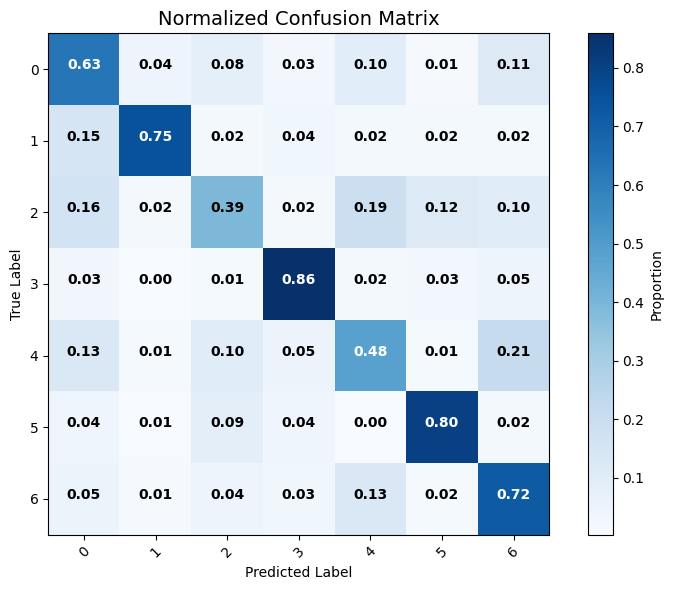

In [ ]:
# ==========================================================
# ✅ Evaluate Model on Unseen Test Data (with Annotated Confusion Matrix)
# ==========================================================
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Ensure generator order is consistent
test_gen.reset()

# Predict probabilities for each class
predictions = model.predict(test_gen, verbose=1)

# Get predicted class indices
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Overall test accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Final Test Accuracy: {acc*100:.2f}%")

# Detailed classification report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("\n📊 Classification Report:\n", report)

# Confusion matrix (normalized)
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Normalized Confusion Matrix', fontsize=14)
plt.colorbar(label='Proportion')

tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

# Add text annotations (normalized values)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]:.2f}",

                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=10, weight='bold')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


In [ ]:
model.save('CNN_model.h5')

In [ ]:
%pwd

'/content'

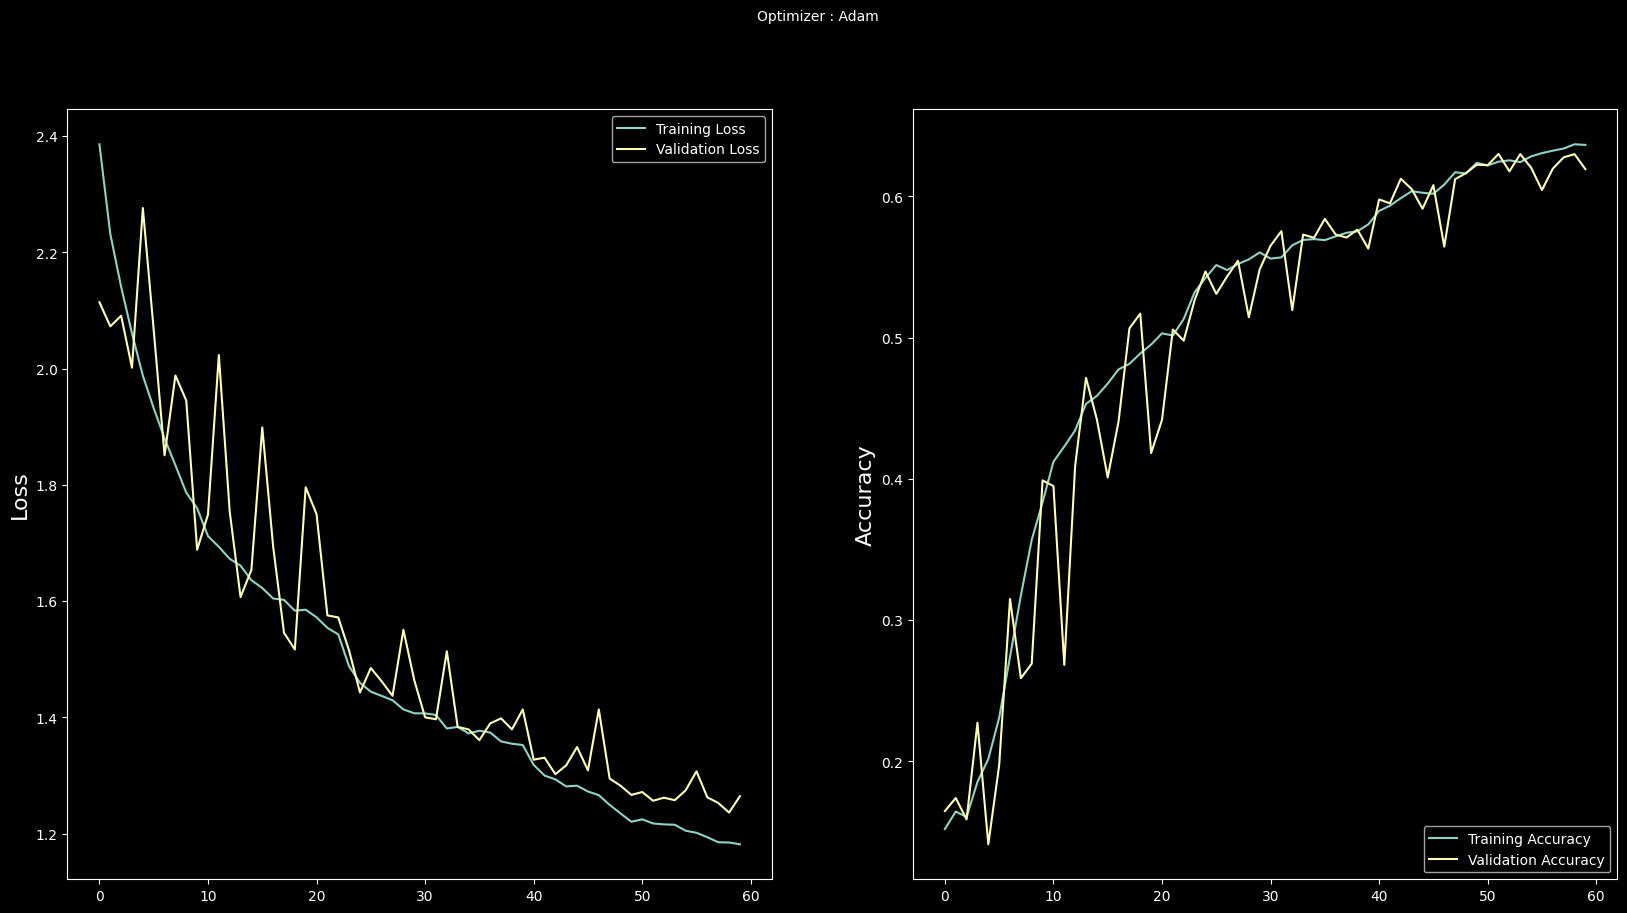

In [ ]:
#Plotting Accuracy & Loss
plt.style.use('dark_background')

plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : Adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

In [ ]:
!mkdir -p /content/drive/MyDrive/Emotion_Detection_Project
!cp /content/CNN_model.h5 /content/drive/MyDrive/Emotion_Detection_Project/CNN_model.h5


cp: cannot stat '/content/CNN_model.h5': No such file or directory


In [ ]:
!ls "/content/drive/MyDrive/Emotion_Detection_Project"


CNN_model.h5


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/Emotion_Detection_Project/CNN_model.h5') # Load model from Google Drive
print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [ ]:
import requests

# URL for the haarcascade_frontalface_default.xml file on OpenCV's GitHub
cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
cascade_filename = "haarcascade_frontalface_default.xml"

# Download the file
try:
    response = requests.get(cascade_url)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(cascade_filename, 'wb') as f:
        f.write(response.content)
    print(f"✅ Successfully downloaded {cascade_filename}")
except requests.exceptions.RequestException as e:
    print(f"❌ Error downloading cascade file: {e}")
    print("Please check your internet connection or the URL.")


✅ Successfully downloaded haarcascade_frontalface_default.xml


Now that the cascade classifier is downloaded, we can update the face detection cells to use it.

In [ ]:
# Fix for 'AttributeError: module 'cv2' has no attribute 'CascadeClassifier'
!pip uninstall opencv-python -y
!pip install opencv-contrib-python-headless -U
print('✅ OpenCV reinstalled. Please restart the runtime (Runtime > Restart runtime) and then rerun all cells from the beginning, excluding the data download and zip extraction cells if data is already present. Make sure to run the cascade file download cell (cell with ID 2cb9e81e) before running face detection.')

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 9.9 MB/s eta 0:00:00
✅ OpenCV reinstalled. Please restart the runtime (Runtime > Restart runtime) and then rerun all cells from the beginning, excluding the data download and zip extraction cells if data is already present. Make sure to run the cascade file download cell (cell with ID 2cb9e81e) before running face detection.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WIN_20260917_22_17_14_Pro.jpg to WIN_20260917_22_17_14_Pro.jpg


✅ haarcascade_frontalface_default.xml already exists.


Testing on: WIN_20260917_22_17_14_Pro.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step


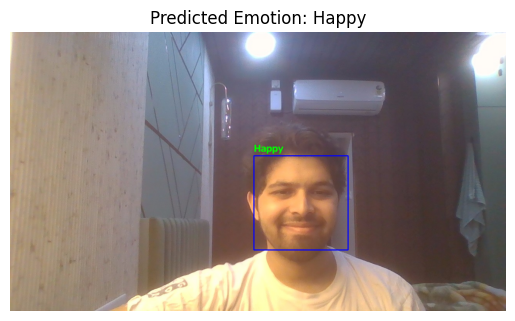

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import requests
import os

# Ensure haarcascade_frontalface_default.xml is available
cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
cascade_filename = "haarcascade_frontalface_default.xml"

if not os.path.exists(cascade_filename):
    try:
        response = requests.get(cascade_url)
        response.raise_for_status() # Raise an exception for HTTP errors
        with open(cascade_filename, 'wb') as f:
            f.write(response.content)
        print(f"✅ Successfully downloaded {cascade_filename}")
    except requests.exceptions.RequestException as e:
        print(f"❌ Error downloading cascade file: {e}")
        print("Please check your internet connection or the URL.")
        # Exit or raise an error if download fails to prevent further errors
        raise SystemExit("Cascade file download failed.")
else:
    print(f"✅ {cascade_filename} already exists.")

# Load your trained model from Google Drive for persistence across restarts
# CNN_model.h5 was saved to Drive in a previous step.
model = load_model('/content/drive/MyDrive/Emotion_Detection_Project/CNN_model.h5')
face_classifier = cv2.CascadeClassifier(cascade_filename) # Use the locally downloaded file

# Emotion labels
emotion_labels = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprise']

# Path to uploaded image
img_path = list(uploaded.keys())[0]
print("Testing on:", img_path)

# Read and convert image
frame = cv2.imread(img_path)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

faces = face_classifier.detectMultiScale(gray, 1.3, 5)

for (x,y,w,h) in faces:
    roi_gray = gray[y:y+h, x:x+w]
    roi_gray = cv2.resize(roi_gray, (48,48), interpolation=cv2.INTER_AREA)

    roi = roi_gray.astype('float')/255.0
    roi = img_to_array(roi)
    roi = np.expand_dims(roi, axis=0)

    prediction = model.predict(roi)[0]
    label = emotion_labels[prediction.argmax()]

    cv2.rectangle(frame, (x,y), (x+w,y+h), (255,0,0), 2)
    cv2.putText(frame, label, (x,y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

# Show output
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Predicted Emotion: {label}")
plt.show()

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
from PIL import Image
from io import BytesIO

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = '📸 Take Photo';
        div.appendChild(capture);
        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // Resize the output to fit the video element.
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        // Wait for capture
        await new Promise((resolve) => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());
        div.remove();
        const dataUrl = canvas.toDataURL('image/jpeg', quality);
        return dataUrl;
      }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


<IPython.core.display.Javascript object>

Saved to: photo.jpg


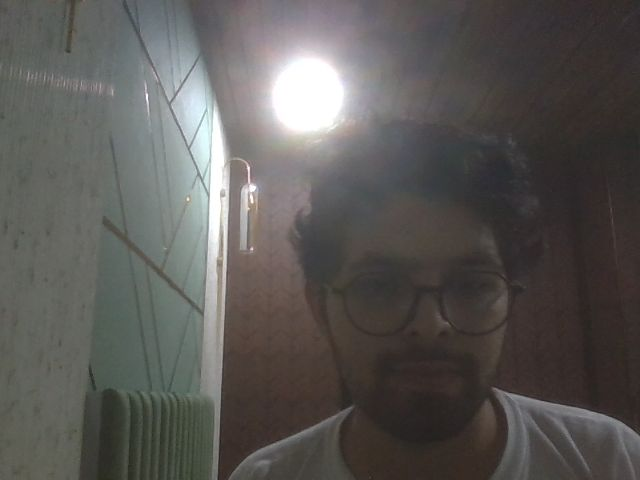

In [ ]:
from IPython.display import Image as IPImage
try:
    filename = take_photo()
    print("Saved to:", filename)
    display(IPImage(filename))
except Exception as e:
    print("Error:", str(e))


Using captured image file: photo.jpg
No faces detected in the image.


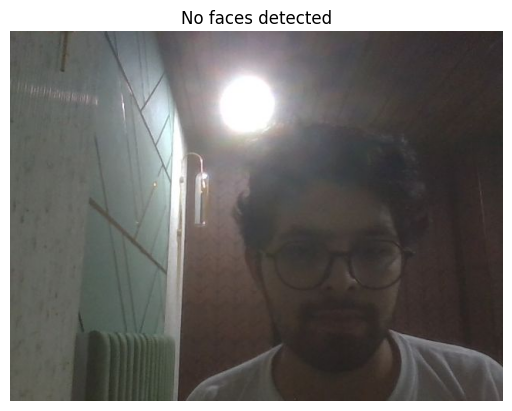

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array # Import img_to_array
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load your trained model (ensure this is the best performing model)
model = load_model('/content/CNN_model.h5') # Load the best model saved during training

face_classifier = cv2.CascadeClassifier('haarcascade_frontalface_default.xml') # Use the locally downloaded file
emotion_labels = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprise']

# Ensure 'filename' is defined by running the take_photo() cell (2g4QlHSGwfEO) first
if 'filename' not in locals():
    print("Error: 'filename' not defined. Please run the 'take_photo()' cell (2g4QlHSGwfEO) first.")
else:
    print(f"Using captured image file: {filename}")
    frame = cv2.imread(filename)

    # Check if image was loaded successfully
    if frame is None:
        print(f"Error: Could not load image from {filename}. Please check the path and file existence.")
    else:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_classifier.detectMultiScale(gray, 1.3, 5)

        if len(faces) == 0:
            print("No faces detected in the image.")
            plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title("No faces detected")
            plt.show()
        else:
            for (x, y, w, h) in faces:
                roi_gray = gray[y:y+h, x:x+w]
                roi_gray = cv2.resize(roi_gray, (48,48), interpolation=cv2.INTER_AREA)
                roi = roi_gray.astype('float')/255.0
                roi = np.expand_dims(img_to_array(roi), axis=0)

                prediction = model.predict(roi)[0]
                label = emotion_labels[prediction.argmax()]
                cv2.rectangle(frame, (x,y), (x+w,y+h), (255,0,0), 2)
                cv2.putText(frame, label, (x,y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

            plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title(f"Predicted Emotion: {label}")
            plt.show()